Data Diet Rekomendasi 
sumber: https://www.kaggle.com/datasets/laurenvalentina/rekomendasi-makanan-gizi-anak/code

Pertanyaan Bisnis:
- Makanan apa yang memiliki kandungan kalori tertinggi pada dataset makanan anak?
- Kategori makanan apa yang memiliki rata-rata kandungan gula tertinggi?
- Apakah terdapat hubungan antara kandungan lemak dan jumlah kalori pada makanan anak?
- Nutrisi apa yang memiliki variasi nilai paling tinggi pada dataset makanan anak?

LIBRARY

In [85]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.set_style('whitegrid') #mengatur gaya visualisasi seaborn menjadi 'whitegrid' untuk tampilan yang lebih bersih dan terstruktur.

GATHERING DATA

In [86]:
# Load dataset
df = pd.read_csv('http://raw.githubusercontent.com/ekasaaa/analisis-dataset-gizi/refs/heads/main/preprocessed_dataset.csv')
df.head()

,Unnamed: 0,Nama,Kategori,Jumlah Porsi,Takaran Porsi,Kalori (kal),Lemak (g),Lemak Jenuh (g),Lemak Tak Jenuh Ganda (g),Lemak Tak Jenuh Tunggal (g),Kolestrol (g),Protein (g),Karbohidrat (g),Serat (g),Gula (g),Sodium (g),Kalium (g)
0,0,Alpukat,Buah Buahan,100,gram (g),160.0,14.66,2.126,1.816,9.799,0.0,2.00,8.53,6.7,0.66,7.0,485.0
1,1,Guacamole,Buah Buahan,1,sdm,23.0,2.08,0.302,0.258,1.393,0.0,0.29,1.24,1.0,0.10,22.0,69.0
2,2,Guacamole dengan Tomat,Buah Buahan,100,gram (g),116.0,9.94,1.446,1.258,6.625,0.0,1.62,7.64,4.9,1.37,201.0,393.0
3,3,Guacamole dengan Tomat dan Cabe Paprika,Buah Buahan,1,mangkok,266.0,22.72,3.304,2.882,15.129,0.0,3.77,17.75,11.4,3.31,459.0,913.0
4,4,Buah Anggur,Buah Buahan,1,tanpa biji,3.0,0.01,0.003,0.002,0.000,0.0,0.04,0.90,0.0,0.77,0.0,10.0


In [87]:
#PARSING
df.columns

Index(['Unnamed: 0', 'Nama', 'Kategori', 'Jumlah Porsi', 'Takaran Porsi',
       'Kalori (kal)', 'Lemak (g)', 'Lemak Jenuh (g)',
       'Lemak Tak Jenuh Ganda (g)', 'Lemak Tak Jenuh Tunggal (g)',
       'Kolestrol (g)', 'Protein (g)', 'Karbohidrat (g)', 'Serat (g)',
       'Gula (g)', 'Sodium (g)', 'Kalium (g)'],
      dtype='object')

ASSESSING DATA

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   392 non-null    int64  
 1   Nama                         392 non-null    object 
 2   Kategori                     392 non-null    object 
 3   Jumlah Porsi                 392 non-null    int64  
 4   Takaran Porsi                392 non-null    object 
 5   Kalori (kal)                 392 non-null    float64
 6   Lemak (g)                    392 non-null    float64
 7   Lemak Jenuh (g)              392 non-null    float64
 8   Lemak Tak Jenuh Ganda (g)    392 non-null    float64
 9   Lemak Tak Jenuh Tunggal (g)  392 non-null    float64
 10  Kolestrol (g)                392 non-null    float64
 11  Protein (g)                  392 non-null    float64
 12  Karbohidrat (g)              392 non-null    float64
 13  Serat (g)           

In [89]:
#Mengecek missing values pada dataset makanan anak

df.isna().sum()

Unnamed: 0                     0
Nama                           0
Kategori                       0
Jumlah Porsi                   0
Takaran Porsi                  0
Kalori (kal)                   0
Lemak (g)                      0
Lemak Jenuh (g)                0
Lemak Tak Jenuh Ganda (g)      0
Lemak Tak Jenuh Tunggal (g)    0
Kolestrol (g)                  0
Protein (g)                    0
Karbohidrat (g)                0
Serat (g)                      0
Gula (g)                       0
Sodium (g)                     0
Kalium (g)                     0
dtype: int64

In [90]:
#Mengecek duplikasi tabel df

print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


In [91]:
#Mengecek menggunakan method describe

df.describe()

,Unnamed: 0,Jumlah Porsi,Kalori (kal),Lemak (g),Lemak Jenuh (g),Lemak Tak Jenuh Ganda (g),Lemak Tak Jenuh Tunggal (g),Kolestrol (g),Protein (g),Karbohidrat (g),Serat (g),Gula (g),Sodium (g),Kalium (g)
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,200.619898,60.117347,115.135204,4.513036,1.594901,0.743388,1.576679,27.736821,7.379974,11.780663,3.237755,4.817041,224.307806,243.438776
std,116.724481,48.598480,103.052514,7.186352,3.933808,1.395391,2.548437,54.463439,8.762099,16.060288,9.950697,10.344179,305.736756,238.418857
min,0.000000,1.000000,2.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,100.750000,1.000000,42.000000,0.237500,0.038750,0.065750,0.026750,0.000000,1.045000,0.675000,0.000000,0.047500,6.000000,79.500000
50%,200.500000,100.000000,86.000000,1.370000,0.356000,0.259500,0.303000,0.000000,3.135000,6.145000,1.100000,1.145000,81.500000,206.000000
75%,302.250000,100.000000,149.250000,5.935000,1.666250,0.926750,2.124250,31.000000,10.957500,16.817500,2.700000,4.205000,344.250000,320.250000
max,400.000000,100.000000,660.000000,64.530000,57.218000,12.170000,15.129000,400.000000,35.750000,82.360000,83.000000,65.000000,1887.000000,1744.000000


CLEANING DATA

In [92]:
# Menghapus kolom index tidak penting
df = df.drop(columns=['Unnamed: 0'])

In [93]:
#cek
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nama                         392 non-null    object 
 1   Kategori                     392 non-null    object 
 2   Jumlah Porsi                 392 non-null    int64  
 3   Takaran Porsi                392 non-null    object 
 4   Kalori (kal)                 392 non-null    float64
 5   Lemak (g)                    392 non-null    float64
 6   Lemak Jenuh (g)              392 non-null    float64
 7   Lemak Tak Jenuh Ganda (g)    392 non-null    float64
 8   Lemak Tak Jenuh Tunggal (g)  392 non-null    float64
 9   Kolestrol (g)                392 non-null    float64
 10  Protein (g)                  392 non-null    float64
 11  Karbohidrat (g)              392 non-null    float64
 12  Serat (g)                    392 non-null    float64
 13  Gula (g)            

In [94]:
# Kolom numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Kolom kategorikal
categorical_cols = df.select_dtypes(include=['object']).columns

print("Kolom Numerik:")
print(numeric_cols)

print("\nKolom Kategorikal:")
print(categorical_cols)

Kolom Numerik:
Index(['Jumlah Porsi', 'Kalori (kal)', 'Lemak (g)', 'Lemak Jenuh (g)',
       'Lemak Tak Jenuh Ganda (g)', 'Lemak Tak Jenuh Tunggal (g)',
       'Kolestrol (g)', 'Protein (g)', 'Karbohidrat (g)', 'Serat (g)',
       'Gula (g)', 'Sodium (g)', 'Kalium (g)'],
      dtype='object')

Kolom Kategorikal:
Index(['Nama', 'Kategori', 'Takaran Porsi'], dtype='object')


In [95]:
#Mengecek missing values pada dataset makanan anak

df.isna().sum()

Nama                           0
Kategori                       0
Jumlah Porsi                   0
Takaran Porsi                  0
Kalori (kal)                   0
Lemak (g)                      0
Lemak Jenuh (g)                0
Lemak Tak Jenuh Ganda (g)      0
Lemak Tak Jenuh Tunggal (g)    0
Kolestrol (g)                  0
Protein (g)                    0
Karbohidrat (g)                0
Serat (g)                      0
Gula (g)                       0
Sodium (g)                     0
Kalium (g)                     0
dtype: int64

HANDLING OUTLIER

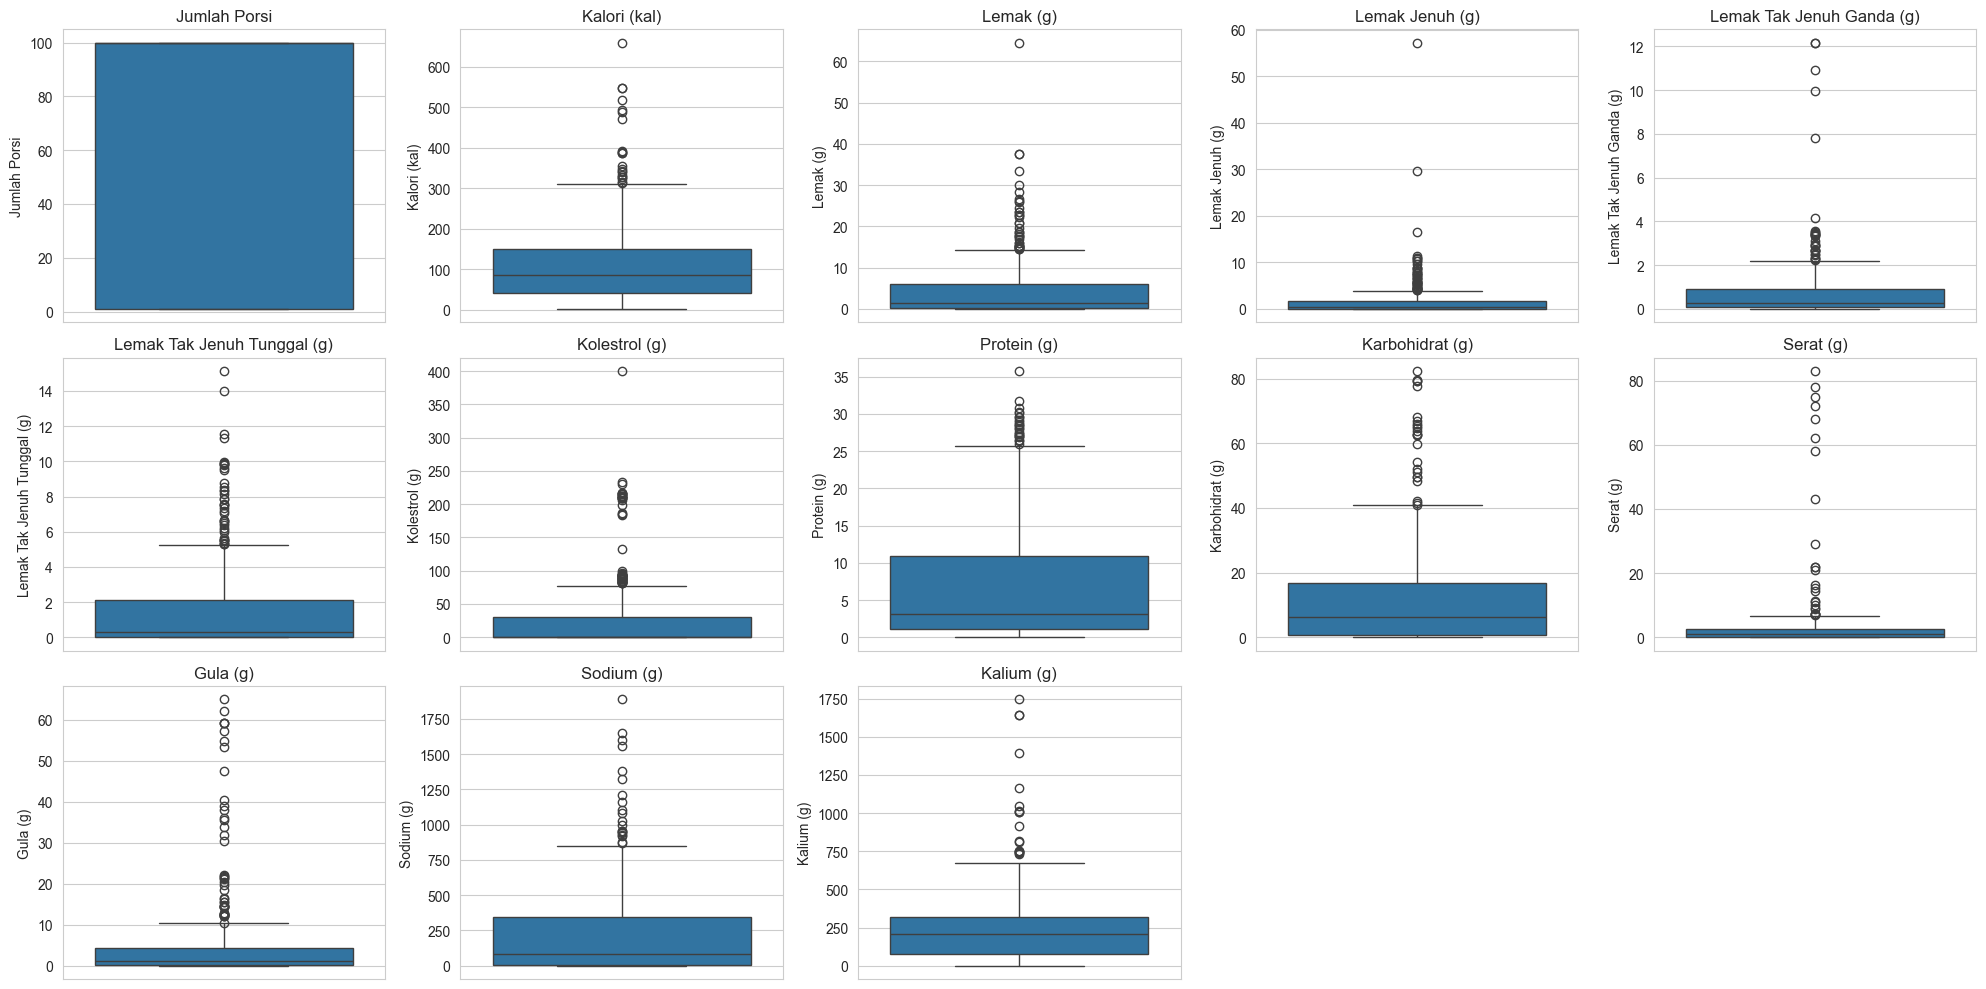

In [96]:
plt.figure(figsize=(20,10))

for i, col in enumerate(numeric_cols):
    
    plt.subplot(3,5,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [97]:
# IDENTIFIKASI OUTLIER (TANPA MENGHAPUS DATA)
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        'Kolom': col,
        'Jumlah Outlier': len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Kolom,Jumlah Outlier
0,Jumlah Porsi,0
1,Kalori (kal),21
2,Lemak (g),36
3,Lemak Jenuh (g),46
4,Lemak Tak Jenuh Ganda (g),29
5,Lemak Tak Jenuh Tunggal (g),40
6,Kolestrol (g),53
7,Protein (g),23
8,Karbohidrat (g),24
9,Serat (g),25


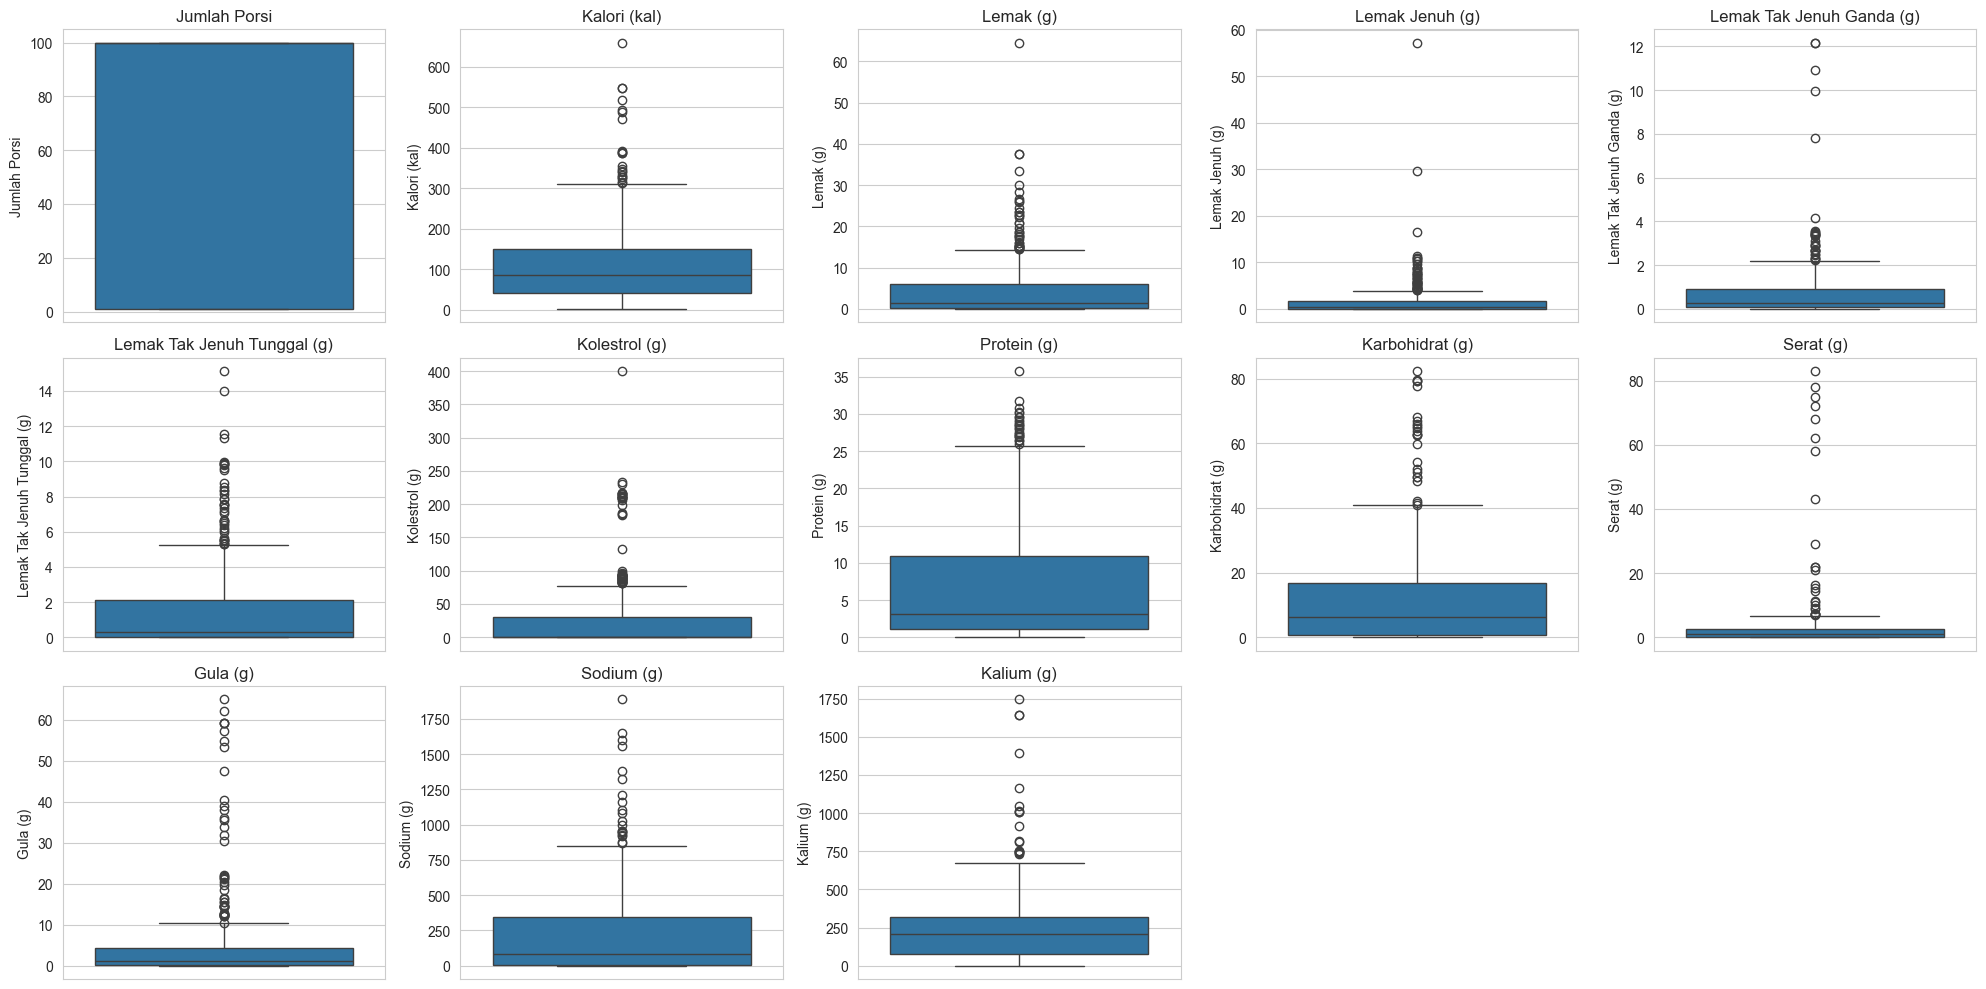

In [98]:
plt.figure(figsize=(20,10))

for i, col in enumerate(numeric_cols):

    plt.subplot(3,5,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

INSIGHT:
- Beberapa fitur nutrisi memiliki outlier, terutama pada kandungan kalori, gula, lemak, dan natrium.

- Outlier pada dataset makanan masih dianggap masuk akal karena setiap makanan memang memiliki kandungan gizi yang sangat bervariasi.

- Contohnya, makanan cepat saji, dessert, atau minuman manis dapat memiliki kandungan gula dan kalori jauh lebih tinggi dibanding makanan lainnya.

- Oleh karena itu, outlier tidak dihapus agar informasi penting mengenai karakteristik makanan tetap terjaga.

EXPLORATORY DATA ANALYSIS (EDA)

Analisis Pertanyaan 1:

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_14496\215418840.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


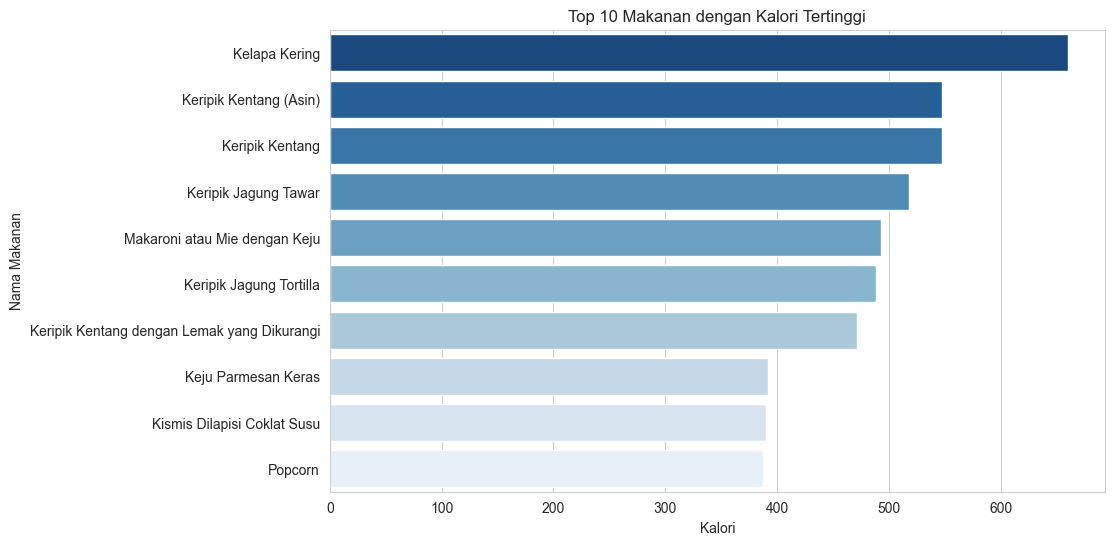

In [99]:
top_kalori = df.sort_values(by='Kalori (kal)', ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_kalori,
    x='Kalori (kal)',
    y='Nama',
    palette='Blues_r'
)

plt.title('Top 10 Makanan dengan Kalori Tertinggi')
plt.xlabel('Kalori')
plt.ylabel('Nama Makanan')

plt.show()

INSIGHT:
- Beberapa makanan memiliki kandungan kalori yang jauh lebih tinggi dibanding makanan lainnya.

- Makanan dengan kalori tertinggi umumnya berasal dari kategori makanan cepat saji, dessert, atau makanan tinggi lemak.

- Tingginya kandungan kalori menunjukkan bahwa makanan tersebut perlu dikonsumsi secara bijak oleh anak agar tidak meningkatkan risiko obesitas.

Analisis Pertanyaan 2:

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_14496\2791052818.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


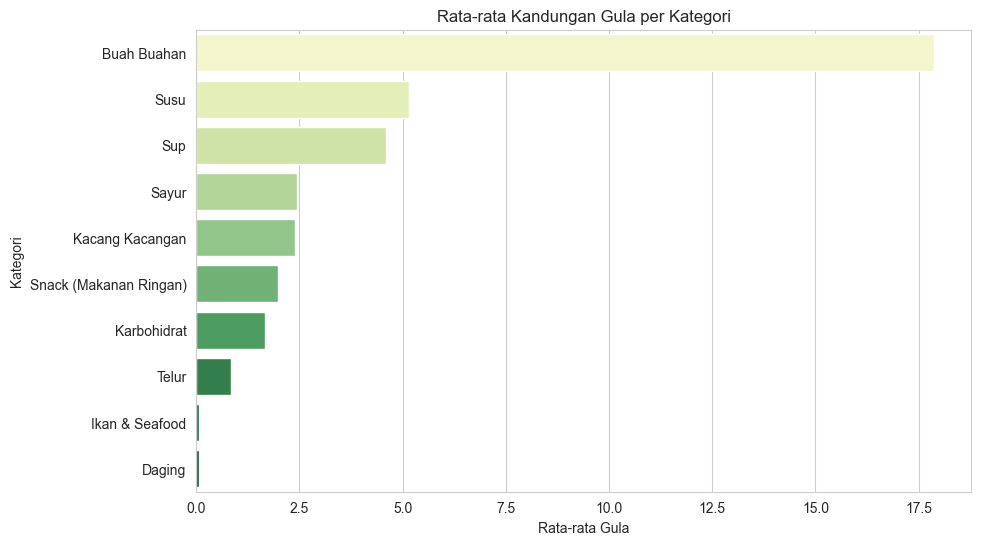

In [100]:
avg_gula = df.groupby('Kategori')['Gula (g)'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_gula.values,
    y=avg_gula.index,
    palette='YlGn'
)

plt.title('Rata-rata Kandungan Gula per Kategori')
plt.xlabel('Rata-rata Gula')
plt.ylabel('Kategori')

plt.show()

INSIGHT:
- Kategori tertentu memiliki rata-rata kandungan gula yang lebih tinggi dibanding kategori lainnya.

- Makanan atau minuman manis cenderung mendominasi kategori dengan kandungan gula tertinggi.

- Konsumsi gula berlebih pada anak perlu diperhatikan karena dapat meningkatkan risiko gangguan kesehatan seperti obesitas dan kerusakan gigi.

Analisis Pertanyaan 3:

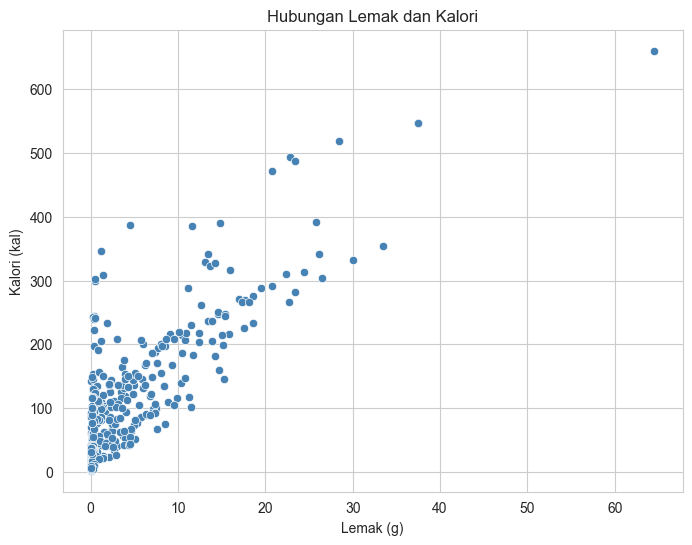

In [101]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Lemak (g)',
    y='Kalori (kal)',
    color='steelblue'
)

plt.title('Hubungan Lemak dan Kalori')
plt.xlabel('Lemak (g)')
plt.ylabel('Kalori (kal)')

plt.show()

In [102]:
korelasi = df['Lemak (g)'].corr(df['Kalori (kal)'])

print("Nilai Korelasi:", korelasi)

Nilai Korelasi: 0.8082596940593785


INSIGHT:
- Terdapat hubungan positif antara kandungan lemak dan jumlah kalori pada makanan anak.

- Semakin tinggi kandungan lemak pada makanan, maka jumlah kalorinya cenderung meningkat.

- Hal ini menunjukkan bahwa lemak menjadi salah satu faktor utama yang memengaruhi tingginya kalori pada makanan.

Analisis Pertanyaan 4:

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_14496\2049644154.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


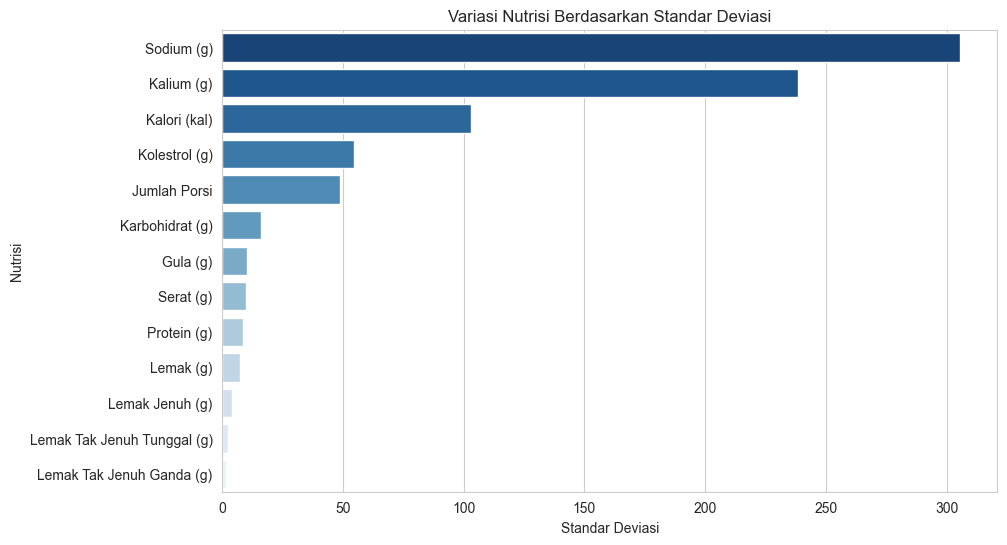

In [103]:
variasi_nutrisi = df[numeric_cols].std().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=variasi_nutrisi.values,
    y=variasi_nutrisi.index,
    palette='Blues_r'
)

plt.title('Variasi Nutrisi Berdasarkan Standar Deviasi')
plt.xlabel('Standar Deviasi')
plt.ylabel('Nutrisi')

plt.show()

INSIGHT:
- Beberapa nutrisi memiliki variasi nilai yang sangat tinggi antar makanan.

- Nutrisi dengan variasi tertinggi menunjukkan bahwa kandungannya sangat beragam pada setiap jenis makanan.

- Variasi ini menggambarkan bahwa dataset memiliki karakteristik makanan yang cukup beragam, mulai dari makanan rendah nutrisi hingga makanan dengan kandungan nutrisi sangat tinggi.

In [104]:
df.to_csv('EDA_Data_Makanan_Anak(revisi).csv', index=False)